In [1]:
library(FLAG)
library(ggplot2)
library(patchwork)


Attaching package: ‘igraph’


The following objects are masked from ‘package:stats’:

    decompose, spectrum


The following object is masked from ‘package:base’:

    union




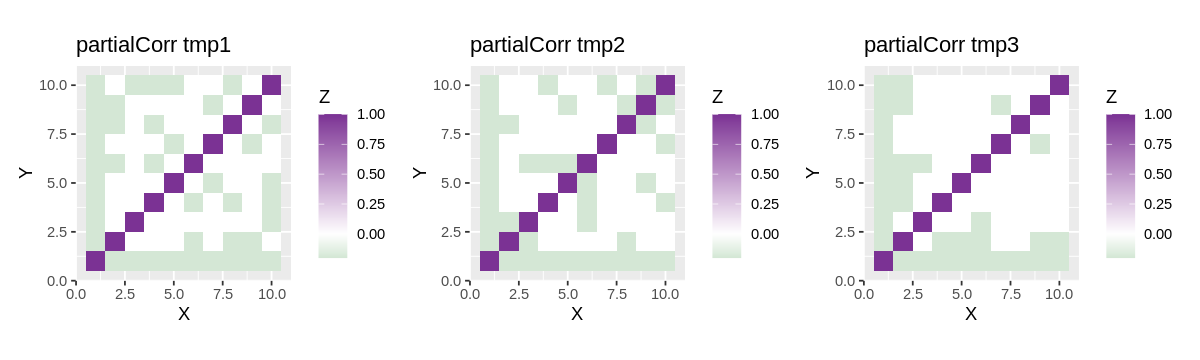

In [2]:
set.seed(0)

get.pc.true <- function(p, sparsity, value=-0.2){
  sparse = rbinom(p*p,1,1-sparsity)*value
  pc = matrix(sparse, p, p)
  pc[,1] = value
  pc[upper.tri(pc)] = t(pc)[upper.tri(pc)]
  diag(pc) = 1
  pc
}

p=10
tmp1 = get.pc.true(p, 0.7)
options(repr.plot.width=10, repr.plot.height=3)
X=Y=1:p
df=expand.grid(X=X, Y=Y)
df$Z=c(tmp1)
p1=ggplot(df, aes(X, Y, fill= Z)) + geom_tile(aes(fill = Z)) + ggtitle('partialCorr tmp1') + coord_fixed() +
      scale_fill_gradient2(low = "#008837", high = "#7b3294", mid = "white", midpoint = 0, limits=c(-0.2, 1))

tmp2 = get.pc.true(p, 0.7)
tmp3 = get.pc.true(p, 0.7)
df$Z=c(tmp2)
p2=ggplot(df, aes(X, Y, fill= Z)) + geom_tile(aes(fill = Z)) + ggtitle('partialCorr tmp2') + coord_fixed() +
      scale_fill_gradient2(low = "#008837", high = "#7b3294", mid = "white", midpoint = 0, limits=c(-0.2, 1))
df$Z=c(tmp3)
p3=ggplot(df, aes(X, Y, fill= Z)) + geom_tile(aes(fill = Z)) + ggtitle('partialCorr tmp3') + coord_fixed() +
      scale_fill_gradient2(low = "#008837", high = "#7b3294", mid = "white", midpoint = 0, limits=c(-0.2, 1))
p1+p2+p3

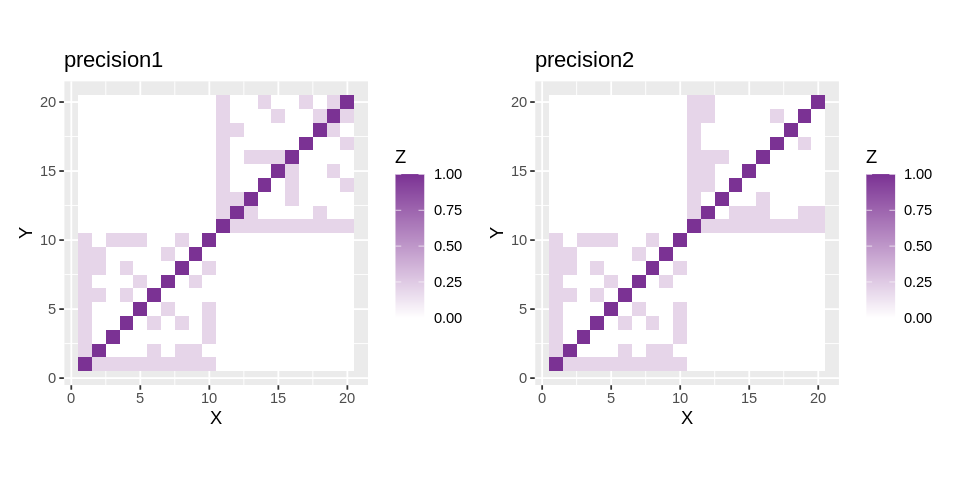

In [3]:
P = 2*p
sigma.list = c(rep(1,P))
pc1 = matrix(0, P, P)
pc1[1:p, 1:p] = tmp1
pc1[(p+1):P, (p+1):P] = tmp2
Pre1 = -diag(sigma.list) %*% pc1 %*% diag(sigma.list)
diag(Pre1) = -diag(Pre1)
X=Y=1:P
df=expand.grid(X=X, Y=Y)
df$Z=c(Pre1)
p1 = ggplot(df, aes(X, Y, fill= Z)) + geom_tile(aes(fill = Z)) + ggtitle('precision1') + coord_fixed() +
      scale_fill_gradient2(low = "#008837", high = "#7b3294", mid = "white", midpoint = 0, limits=c(0, 1))

pc2 = matrix(0, P, P)
pc2[1:p, 1:p] = tmp1
pc2[(p+1):P, (p+1):P] = tmp3
Pre2 = -diag(sigma.list) %*% pc2 %*% diag(sigma.list)
diag(Pre2) = -diag(Pre2)
options(repr.plot.width=8, repr.plot.height=4)
X=Y=1:P
df=expand.grid(X=X, Y=Y)
df$Z=c(Pre2)
p2 = ggplot(df, aes(X, Y, fill= Z)) + geom_tile(aes(fill = Z)) + ggtitle('precision2') + coord_fixed() +
      scale_fill_gradient2(low = "#008837", high = "#7b3294", mid = "white", midpoint = 0, limits=c(0, 1))

p1+p2

In [4]:
get.meta_oneEdge<-function(P, om1, om2){
  om.meta.rho.pval = matrix(0, P, P)
  om.meta.prec1 = diag( diag(om1$precision.est) )
  om.meta.prec2 = diag( diag(om2$precision.est) )

      rho1 = om1$rho.est
      rho2 = om2$rho.est
      rho.se1 = om1$rho.se
      rho.se2 = om2$rho.se
      rho.pval1 = om1$partialcor.pval
      rho.pval2 = om2$partialcor.pval
      test.stat = (rho1 - rho2) / sqrt( rho.se1^2 + rho.se2^2 )
      test.pval = pchisq(test.stat^2, 1, lower.tail = F)
      if(is.na(test.pval)==TRUE | test.pval<0.05){
        meta.rho = NaN
        meta.rho.se = NaN
        meta.rho.pval = NaN
      }
      else{
        rho.list = c(rho1, rho2)
        w.list = c( 1/(rho.se1^2), 1/(rho.se2^2) )
        w.sum = sum(w.list)
        meta.rho = sum(w.list * rho.list) / w.sum
        meta.rho.se = 1 / sqrt(w.sum)
        meta.rho.pval = pchisq((meta.rho / meta.rho.se)^2, 1, lower.tail = F)
      }
  meta.rho.pval
}

In [6]:
Sigma1 = solve(Pre1)
Sigma2 = solve(Pre2)
N1 = 80
N2 = 120

rep.times = 500
meta.null.times = 0
meta.alter.times = 0
om.1.null = 0
om.2.null = 0
om.meta.null = 0
om.1.alter = 0
om.2.alter = 0
om.meta.alter = 0

start=Sys.time()
for(rep in 1:rep.times){
  Z1 = MASS::mvrnorm(N1, rep(0, P), Sigma1)
  Z1 = scale(Z1, center = T, scale = F)
  Z2 = MASS::mvrnorm(N2, rep(0, P), Sigma2)
  Z2 = scale(Z2, center = T, scale = F)

  null.i = 1
  null.j = P
  om1 = FlagOneEdge(Z1, null.i, null.j, infer='wald')
  om.1.null = om.1.null + ifelse(om1$partialcor.pval<0.05, 1, 0)
  om2 = FlagOneEdge(Z2, null.i, null.j, infer='wald')
  om.2.null = om.2.null + ifelse(om2$partialcor.pval<0.05, 1, 0)
  om.meta = get.meta_oneEdge(P, om1, om2)
  if(!is.na(om.meta)){
    om.meta.null = om.meta.null + ifelse(om.meta<0.05, 1, 0)
    meta.null.times = meta.null.times + 1
  }
  
    
  alter.i = 1
  alter.j = p
  om1 = FlagOneEdge(Z1, alter.i, alter.j, infer='wald')
  om.1.alter = om.1.alter + ifelse(om1$partialcor.pval<0.05, 1, 0)
  om2 = FlagOneEdge(Z2, alter.i, alter.j, infer='wald')
  om.2.alter = om.2.alter + ifelse(om2$partialcor.pval<0.05, 1, 0)
  om.meta = get.meta_oneEdge(P, om1, om2)
  if(!is.na(om.meta)){
    om.meta.alter = om.meta.alter + ifelse(om.meta<0.05, 1, 0)
    meta.alter.times = meta.alter.times + 1
  }
}

cat('null cases:', meta.null.times, 'for meta analysis\n')
cat('Group 1: False positive rate = ', om.1.null/rep.times, '\n')
cat('Group 2: False positive rate = ', om.2.null/rep.times, '\n')
cat('Group meta: False positive rate = ', om.meta.null/meta.null.times, '\n')

cat('alternative cases:', meta.alter.times, 'for meta analysis\n')
cat('Group 1: True positive rate = ', om.1.alter/rep.times, '\n')
cat('Group 2: True positive rate = ', om.2.alter/rep.times, '\n')
cat('Group meta: True positive rate = ', om.meta.alter/meta.alter.times, '\n')

end=Sys.time()
print(end-start)

Warning message in sqrt(d %*% Gamma_e_cov %*% t(d)):
“NaNs produced”


null cases: 457 for meta analysis
Group 1: False positive rate =  NA 
Group 2: False positive rate =  0.068 
Group meta: False positive rate =  0.06564551 
alternative cases: 468 for meta analysis
Group 1: True positive rate =  0.416 
Group 2: True positive rate =  0.582 
Group meta: True positive rate =  0.7905983 
Time difference of 2.170604 mins


In [8]:
power.sd <- function(power, n){
  sqrt( power*(1-power)/n )
}

fpr.1 = om.1.null/rep.times
fpr.2 = om.2.null/rep.times
fpr.meta = om.meta.null/meta.null.times

tpr.1 = om.1.alter/rep.times
tpr.2 = om.2.alter/rep.times
tpr.meta = om.meta.alter/meta.alter.times

df.null = data.frame(pr = c(fpr.1, fpr.2, fpr.meta),
                     sd = c(power.sd(fpr.1, rep.times), power.sd(fpr.2, rep.times), power.sd(fpr.meta, meta.null.times)),
                     group=c('Group 1', 'Group 2', 'Meta-analysis'))
df.null$case = ("Null cases")
df.alter = data.frame(pr = c(tpr.1, tpr.2, tpr.meta), 
                      sd = c(power.sd(tpr.1, rep.times), power.sd(tpr.2, rep.times), power.sd(tpr.meta, meta.alter.times)),
                      group=c('Group 1', 'Group 2', 'Meta-analysis'))
df.alter$case = ("Alternative cases")
df = rbind(df.null, df.alter)
df$case = factor(df$case, levels=c('Null cases', 'Alternative cases'))

Warning message:
“Removed 1 rows containing missing values (`geom_bar()`).”
Warning message:
“Removed 1 rows containing missing values (`geom_text()`).”


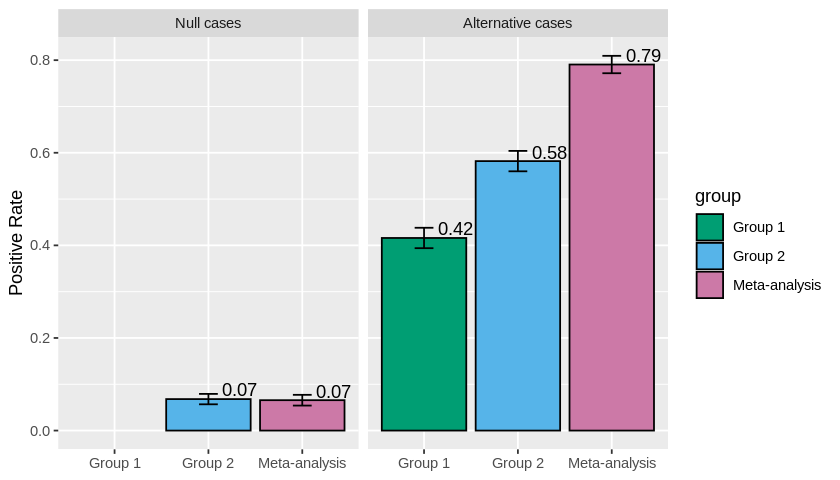

In [9]:
options(repr.plot.width=7, repr.plot.height=4)
ggplot(df, aes(x=group, y=pr, fill=group)) + geom_bar(stat="identity", color="black", 
           position=position_dodge()) +
  scale_fill_manual(values=c('#009E73','#56B4E9','#CC79A7')) +
  facet_wrap(.~case, nrow=1) + ylab("Positive Rate") + xlab(NULL) +
  geom_errorbar(aes(ymin=pr-sd, ymax=pr+sd), width=.2,
                 position=position_dodge(.9))+
  geom_text(aes(label = round(pr,2)), vjust = -0.2, hjust = -0.4)

In [11]:
save.image("positive_rates_barplot.RData")